# Animation: A Rotating Reference Frame

A key insight of Coordinatus is that **the same point has different coordinates
depending on your reference frame**.

This notebook animates that idea:
- A **world space** (black axes) stays fixed.
- A **rotating frame** (blue axes) spins continuously around the world origin.
- A **fixed point** (red) is defined in world coordinates and never moves.

Watch how the red dot's coordinates in the rotating frame change every frame,
even though it never physically moves. The animation is saved as a GIF so you
can see it directly on GitHub.

![Rotating frame animation](./rotating_frame.gif)


In [1]:
import os
from pathlib import Path

# Resolve the directory that contains this notebook so that
# the GIF is always written next to it, regardless of the kernel CWD.
try:
    # nbconvert sets __session__ or passes the notebook path via env var
    _nb_path = os.environ.get('JPY_SESSION_NAME', '') or os.getcwd()
    NB_DIR = Path(_nb_path) if Path(_nb_path).is_dir() else Path(_nb_path).parent
    # Fallback: if CWD already contains the notebooks folder, we're in repo root
    if (Path(os.getcwd()) / 'notebooks').is_dir():
        NB_DIR = Path(os.getcwd()) / 'notebooks'
    elif Path(os.getcwd()).name == 'notebooks':
        NB_DIR = Path(os.getcwd())
except Exception:
    NB_DIR = Path(os.getcwd())

print('Notebook directory:', NB_DIR)


Notebook directory: D:\DataEmmanuel\Programmation\Packages\Coordinatus\notebooks


In [2]:
import numpy as np
import matplotlib
matplotlib.use("Agg")  # non-interactive backend for saving
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

from coordinatus import Space2D, Space, Point, Vector
from coordinatus.transforms import rotate2D


In [3]:
world = Space2D()
fixed_point_world = Point(np.array([1.5, 0.8]), space=world)

N_FRAMES = 60
angles = np.linspace(0, 2 * np.pi, N_FRAMES, endpoint=False)
AXIS_LEN = 1.0
ARROW_KW = dict(head_width=0.08, head_length=0.08, length_includes_head=True, zorder=4)

def draw_axes(ax, origin, x_vec, y_vec, color, label, alpha=1.0):
    ax.plot(*origin, 'o', color=color, markersize=7, zorder=5, alpha=alpha)
    ax.arrow(*origin, *x_vec, fc=color, ec=color, alpha=alpha, **ARROW_KW)
    ax.arrow(*origin, *y_vec, fc=color, ec=color, alpha=alpha, **ARROW_KW)
    ax.text(origin[0] + x_vec[0] + 0.08, origin[1] + x_vec[1],
            label + ' X', color=color, fontsize=8, alpha=alpha)
    ax.text(origin[0] + y_vec[0], origin[1] + y_vec[1] + 0.08,
            label + ' Y', color=color, fontsize=8, alpha=alpha)

def setup_ax(ax, title):
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5, alpha=0.4)
    ax.axvline(0, color='k', lw=0.5, alpha=0.4)

wp = fixed_point_world.to_absolute().coords
fig, (ax_world, ax_local) = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('A Fixed Point Seen from a Rotating Frame', fontsize=13)

def update(frame_idx):
    ax_world.cla()
    ax_local.cla()
    setup_ax(ax_world, 'View from World (absolute)')
    setup_ax(ax_local, 'View from Rotating Frame')
    angle = angles[frame_idx]
    rotating = Space(transform=rotate2D(angle), parent=world)

    draw_axes(ax_world, [0, 0], [AXIS_LEN, 0], [0, AXIS_LEN],
              color='black', label='World', alpha=0.35)
    rx = Vector(np.array([1, 0]), space=rotating).to_absolute().coords * AXIS_LEN
    ry = Vector(np.array([0, 1]), space=rotating).to_absolute().coords * AXIS_LEN
    draw_axes(ax_world, [0, 0], rx, ry, color='royalblue', label='Frame')
    ax_world.plot(*wp, 'o', color='crimson', markersize=10, zorder=6, label='Fixed point')
    ax_world.text(wp[0] + 0.1, wp[1] + 0.1,
                  'world: ({:.2f}, {:.2f})'.format(wp[0], wp[1]),
                  fontsize=8, color='crimson')
    ax_world.legend(loc='upper left', fontsize=8)

    wo_x = Vector(np.array([1, 0]), space=world).relative_to(rotating).coords * AXIS_LEN
    wo_y = Vector(np.array([0, 1]), space=world).relative_to(rotating).coords * AXIS_LEN
    draw_axes(ax_local, [0, 0], wo_x, wo_y, color='black', label='World', alpha=0.35)
    draw_axes(ax_local, [0, 0], [AXIS_LEN, 0], [0, AXIS_LEN],
              color='royalblue', label='Frame')
    lp = fixed_point_world.relative_to(rotating).coords
    ax_local.plot(*lp, 'o', color='crimson', markersize=10, zorder=6, label='Fixed point')
    ax_local.text(lp[0] + 0.1, lp[1] + 0.1,
                  'frame: ({:.2f}, {:.2f})'.format(lp[0], lp[1]),
                  fontsize=8, color='crimson')
    ax_local.legend(loc='upper left', fontsize=8)

    for ax in (ax_world, ax_local):
        ax.text(0.02, 0.02, 'theta = {:.0f} deg'.format(np.degrees(angle)),
                transform=ax.transAxes, fontsize=9, color='royalblue',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=80)
gif_path = str(NB_DIR / 'rotating_frame.gif')
anim.save(gif_path, writer=PillowWriter(fps=15))
plt.close(fig)
print('GIF saved to', gif_path)


GIF saved to D:\DataEmmanuel\Programmation\Packages\Coordinatus\notebooks\rotating_frame.gif


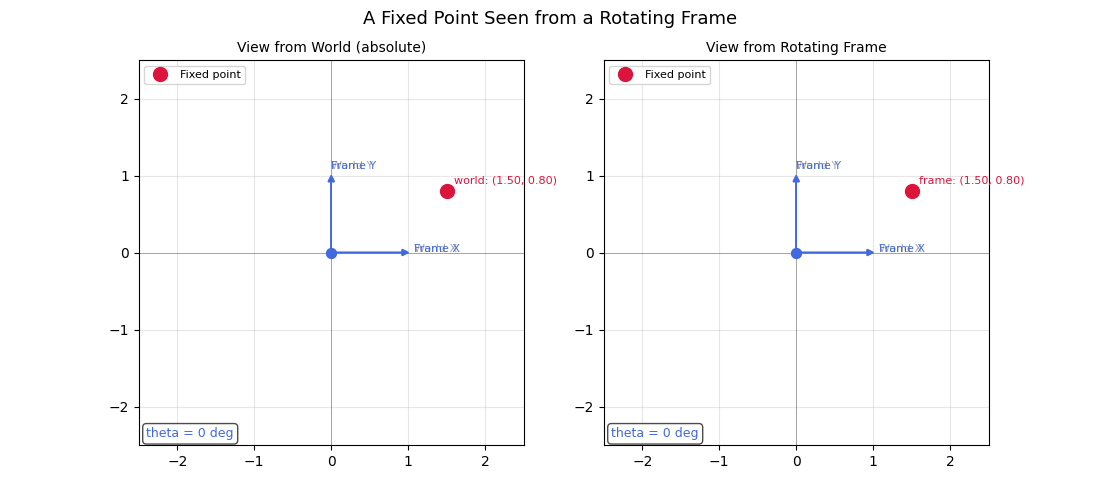

In [4]:
from IPython.display import Image
Image(str(NB_DIR / 'rotating_frame.gif'))


## Reading the animation

| Panel | What you see |
|---|---|
| **Left — World view** | The red dot never moves. The blue frame rotates around it. The world coordinates of the red dot stay constant at `(1.50, 0.80)`. |
| **Right — Frame view** | The blue frame axes are always aligned with the plot X/Y axes (it is their own frame). The red dot appears to orbit around the origin, and its coordinates in the frame change every tick. |

**The takeaway:** the red dot's numerical coordinates depend entirely on which space you ask.
Call `point.relative_to(rotating_frame)` and you get its position expressed in the frame's
own language — different numbers, same physical point. This is what Coordinatus automates.
